# FIP 07 — DA × NE summary: correlation, transients, task responses

Three figures that collect the DA × NE results of `fip_04` and `fip_05` on one dataset, with one
set of conventions.

1. **Correlation and coherence of the whole-session traces** (the `fip_04` analyses).
2. **Large transients**: how often a large transient in one signal has a partner in the other
   (`fip_05` section 5).
3. **Task-aligned responses**: outcome- and RPE-sorted averages, and trial-by-trial coupling of
   response size and timing. This figure is drawn once per response window: Rachel's
   0.33–1 s after the choice, and `fip_05`'s 0–0.5, 0.5–2 and 0–2 s after the outcome.

**Signals.** "DA" is dLight in lateral NAc (`latNAcc(X)-DA`). "NE" is GCaMP in LC noradrenergic
axons imaged in PL (`PL(X)-LCAxonCa`): axonal calcium, not transmitter release. Both are
`dff-bright_mc-iso-IRLS` dF/F. dLight and GCaMP have different kinetics, so lags describe the
recorded signals.

**Data.** The CSV-curated builds of `DANE_3channels_curated` and the 4-channel rebuild, curated
when built. Each animal contributes one hemisphere (`fc.choose_side`), with DA and NE from that
side. 808056 is not in the 4-channel rebuild, so it is absent here although `fip_04` has it.

**Which code computes what.** Figure 3 uses Rachel's pipeline: `dummy_nwb.load` for loading,
`trial_metrics.get_average_signal_window` for window means and `alignment.event_triggered_response`
for aligned traces, all on her `data_z_norm` (session z-score minus each trial's mean over the 1 s
before the go cue). Her `Qch-binned3` column sorts trials by outcome and chosen value. Her libraries
have no cross-correlation, coherence, transient or latency functions; those come from `fip_04`,
`fip_05` (`fip_coupling.py`) and `fip_utils.norm_xcorr`, on each trace z-scored over the session.

**Conventions.**
- Lag and latency differences are signed so that **positive = NE later**.
- Sessions are averaged within animal, then across animals. Error bands are SEM over animals and
  tests are Wilcoxon signed-rank on animal means (smallest two-sided p with 9 animals: 0.004).
- Colors: DA vermillion, NE blue, rewarded orange, unrewarded grey; totals and grand means black.
- Outcome time and choice time are the same event in these sessions (they differ by ≤ 1 ms), so
  all four windows are measured from one alignment point.

## Setup

In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import signal, stats

import fip_coupling as fc
import fip_utils as fu
from rachel_analysis_utils.nwb_utils import dummy_nwb
from aind_dynamic_foraging_data_utils import alignment
from aind_dynamic_foraging_basic_analysis.metrics import trial_metrics
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
PAIRS_CACHE = ("/root/capsule/scratch/fip_05/pairs.pkl" if IS_CO   # shared with fip_05
               else "../../data/fip_05_cache/pairs.pkl")
TRIAL_CACHE = ("/root/capsule/scratch/fip_07/trial_tables.pkl" if IS_CO
               else "../../data/fip_07_cache/trial_tables.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

FS = 20.0                    # Hz, grid rate for the continuous analyses
MIN_SESSIONS_PER_ANIMAL = 3

# ── Figure 1: cross-correlation and coherence (fip_04) ───────────────────────
MAXLAG_S = 3.0
N_SHIFT = 200                # circular shifts per session
MIN_SHIFT_S = 60.0           # smallest circular shift
COH_NPERSEG = 1024           # 51.2-s Welch segments
COH_MAX_HZ = 2.0             # coherence is tested and shown up to here; above it the signals are low-passed noise
CLUSTER_ALPHA = 0.05
EXAMPLE_SESSION = None       # None = the session whose peak r is closest to the median
EXAMPLE_WINDOW_S, EXAMPLE_ZOOM_S = 180.0, 20.0

# ── Figure 2: large transients (fip_05 section 5) ────────────────────────────
LARGE_PROM = 2.0             # z prominence of a "large" transient
PARTNER_PROM = 1.0           # z prominence that counts as a partner in the other signal
MATCH_WIN_S = 0.5            # partner must peak within this many s
MIN_SEP_S = 0.5              # minimum spacing of peaks in one signal (fc.detect_transients)
PROM_BINS = [2.0, 2.5, 3.0, 4.0, np.inf]
CONTEXTS = ["rewarded", "unrewarded", "cue, no response", "licking", "quiet"]

# ── Figure 3: task responses (Rachel's pipeline) ─────────────────────────────
DATA_COL = "data_z_norm"
ALIGN = "choice_time_in_session"          # = outcome time in these sessions
CUE = "goCue_start_time_in_session"
WINDOWS = {                               # s after the choice / outcome
    "rachel": (0.33, 1.0),                # add_AUC_and_rpe_slope default
    "early": (0.0, 0.5),
    "late": (0.5, 2.0),
    "full": (0.0, 2.0),
}
WINDOW_LABEL = {"rachel": "Rachel 0.33–1 s", "early": "early 0–0.5 s", "late": "late 0.5–2 s",
                "full": "full 0–2 s"}
PSTH_T = (-1.0, 3.0)                      # choice-aligned traces
LATENCY_WIN = (0.0, 1.5)                  # peak search after the go cue
MIN_PEAK_Z = 1.0                          # a latency counts only if the peak clears this (z above baseline)
MIN_RPE_SD = 0.05                         # sessions with flatter within-outcome RPE are left out of 3b
QCH_BINS = ["Qch 0", "Qch 0.33", "Qch 0.66"]

# ── Colors ───────────────────────────────────────────────────────────────────
SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"]}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)"}
OUT_COLOR = {"rewarded": OKABE_ITO["orange"], "unrewarded": "0.45"}
TOTAL_COLOR = "k"
NULL_COLOR = PALETTE["not_sig"]
CLUSTER_COLOR = PALETTE["accent"]
# RPE bins, ordered from lowest to highest RPE within each outcome
RPE_BIN_COLOR = {"rewarded": plt.cm.Oranges(np.linspace(0.35, 0.9, 3)),
                 "unrewarded": plt.cm.Greys(np.linspace(0.85, 0.35, 3))}
ANIMAL_HUES = [OKABE_ITO[k] for k in ("orange", "sky_blue", "bluish_green", "blue",
                                      "vermillion", "reddish_purple")]
ANIMAL_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "h"]
rng = np.random.default_rng(0)

## Data

`fc.inventory_pairs` finds every session with a lateral-NAc DA fiber and a PL NE fiber on the same
side; `fc.choose_side` keeps each animal's side with more sessions. `fc.load_pairs` puts both
traces on one 20-Hz grid for Figures 1–2 (the cache is shared with `fip_05`). Figure 3 reloads the
same sessions through Rachel's `dummy_nwb.load` below.

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fc.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

inv = fc.inventory_pairs(asset_roots)
kept, side_table = fc.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)
pairs = fc.load_pairs(kept, fs=FS, cache_path=PAIRS_CACHE)
for p in pairs:
    p["z"] = {s: fc.zscore(p[s]) for s in ("da", "ne")}
    p["t"] = p["t0"] + np.arange(len(p["da"])) / FS

SUBJECTS = sorted({p["subject"] for p in pairs})
N_ANIMALS = len(SUBJECTS)
SUBJ_IDX = np.array([SUBJECTS.index(p["subject"]) for p in pairs])
ANIMAL_STYLE = {s: (ANIMAL_HUES[i % len(ANIMAL_HUES)], ANIMAL_MARKERS[i % len(ANIMAL_MARKERS)])
                for i, s in enumerate(SUBJECTS)}
print(f"{len(pairs)} sessions from {N_ANIMALS} animals")
side_table[side_table.kept]

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data


loaded 97 pairs from cache ../../data/fip_05_cache/pairs.pkl
97 sessions from 9 animals


side,asset,L,R,side_used,n_used,kept
subject,,,,,,
800886,3ch,5,0,L,5,True
808054,4ch,1,16,R,16,True
809487,4ch,8,0,L,8,True
809491,4ch,20,0,L,20,True
815334,4ch,3,4,R,4,True
816212,4ch,8,0,L,8,True
816214,4ch,0,5,R,5,True
818585,3ch,8,0,L,8,True
818586,3ch,23,0,L,23,True


In [4]:
def animal_strip(ax, df, cols, labels, colors, ylabel, title=None, connect=True, zero=True):
    """Per-animal points for several measures, with the mean over animals as a bar.

    df is indexed by subject with one column per measure; lines join one animal's points."""
    x = np.arange(len(cols))
    if connect:
        for _, row in df[cols].iterrows():
            ax.plot(x, row.values, color="0.8", lw=0.8, zorder=1)
    for k, c in enumerate(cols):
        v = df[c].to_numpy(float)
        jitter = (rng.random(len(v)) - 0.5) * 0.15
        ax.scatter(x[k] + jitter, v, s=18, color=colors[k], zorder=2, edgecolor="none")
        m, p, n = fc.wilcoxon_animals(v)
        ax.plot([x[k] - 0.25, x[k] + 0.25], [m, m], color="k", lw=2, zorder=3)
        ax.text(x[k], 1.02, stars(p), transform=ax.get_xaxis_transform(), ha="center", fontsize=8)
    if zero:
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, loc="left", pad=16)
    style_ax(ax)


def grand_trace(ax, mats_by_animal, lags, color, label, ls="-"):
    """Mean ± SEM over animals of per-animal mean traces."""
    A = np.stack(mats_by_animal)
    m = np.nanmean(A, 0)
    se = np.nanstd(A, 0) / np.sqrt(np.isfinite(A).all(1).sum())
    ax.plot(lags, m, color=color, label=label, ls=ls)
    ax.fill_between(lags, m - se, m + se, color=color, alpha=0.2, lw=0)


def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."


def sess_corr(g, a, b, method="pearson"):
    """Correlation of two columns across the rows of g (NaN with 10 or fewer complete rows)."""
    d = g[[a, b]].dropna()
    if len(d) <= 10:
        return np.nan
    return (np.corrcoef(d[a], d[b])[0, 1] if method == "pearson"
            else stats.spearmanr(d[a], d[b])[0])


def animal_stack(arrays):
    """Per-animal means of per-session arrays (sessions in `pairs` order)."""
    A = np.stack(arrays)
    return np.stack([A[SUBJ_IDX == i].mean(0) for i in range(N_ANIMALS)])

## Figure 1. Cross-correlation and coherence

Per session, from `fip_04`: the normalized cross-correlation of the two z-scored task-period traces
(`fu.norm_xcorr(ne, da)`, so a peak at positive lag means NE later) and magnitude-squared coherence
(Welch, 51.2-s segments). Both are compared with 200 circular shifts of NE against DA (at least
60 s), which keep each trace's autocorrelation and remove only their alignment. The grand-mean
null averages shift draw *i* within animal, then across animals.

Coherence is tested with `fip_04`'s cluster-mass test, restricted to ≤ `COH_MAX_HZ`: the signals are
low-passed, and above ~2 Hz the spectra are noise, where `fip_04` found a spurious 5–10 Hz cluster.

In [5]:
def circular_xcorr(a, b):
    """Circular normalized cross-correlation at every shift (FFT); index k matches norm_xcorr's lag k."""
    a = (np.asarray(a, float) - np.mean(a)) / np.std(a)
    b = (np.asarray(b, float) - np.mean(b)) / np.std(b)
    return np.fft.irfft(np.fft.rfft(a) * np.conj(np.fft.rfft(b)), len(a)) / len(a)


def contiguous_runs(mask):
    """[(start, end)] index pairs of each run of True."""
    edges = np.flatnonzero(np.diff(np.r_[0, mask.astype(int), 0]))
    return list(zip(edges[::2], edges[1::2] - 1))


def cluster_test(obs, null, freqs, alpha=CLUSTER_ALPHA):
    """Cluster-mass test on a spectrum against null spectra (fip_03 §3b / fip_04)."""
    thr = np.percentile(null, 95, axis=0)
    null_max = np.array([max([np.sum(nl[a:b + 1] - thr[a:b + 1])
                              for a, b in contiguous_runs(nl > thr)] or [0.0]) for nl in null])
    crit = np.percentile(null_max, 100 * (1 - alpha))
    found = []
    for a, b in contiguous_runs(obs > thr):
        mass = float(np.sum(obs[a:b + 1] - thr[a:b + 1]))
        if mass > crit:
            j = a + int(np.argmax(obs[a:b + 1]))
            found.append(dict(lo_Hz=freqs[a], hi_Hz=freqs[b], peak_coh=float(obs[j]),
                              peak_Hz=float(freqs[j]), mass=mass,
                              p=(1 + int(np.sum(null_max >= mass))) / (1.0 + len(null))))
    return found, thr


K_LAG = int(round(MAXLAG_S * FS))
LAG_IDX = np.arange(-K_LAG, K_LAG + 1)
LAGS = LAG_IDX / FS
MIN_SHIFT = int(round(MIN_SHIFT_S * FS))

rows = []
for p in pairs:
    da, ne = p["z"]["da"], p["z"]["ne"]
    _, cc = fu.norm_xcorr(ne, da, fs=FS, maxlag=MAXLAG_S)     # + lag = NE later
    circ = circular_xcorr(ne, da)
    n = len(circ)
    shifts = rng.integers(MIN_SHIFT, n - MIN_SHIFT, size=N_SHIFT)
    null = circ[(shifts[:, None] + LAG_IDX[None, :]) % n]
    f_coh, coh = signal.coherence(da, ne, fs=FS, nperseg=COH_NPERSEG)
    coh_null = np.stack([signal.coherence(da, np.roll(ne, s), fs=FS, nperseg=COH_NPERSEG)[1]
                         for s in rng.integers(MIN_SHIFT, n - MIN_SHIFT, size=N_SHIFT)])
    k = int(np.argmax(np.abs(cc)))
    null_peaks = np.abs(null).max(1)
    p.update(xc=cc, xc_null=null, coh=coh, coh_null=coh_null.astype(np.float32))
    rows.append(dict(subject=p["subject"], session=p["session"], peak_r=cc[k], peak_lag=LAGS[k],
                     r0=cc[K_LAG], null_peak=np.median(null_peaks),
                     p_shift=(1 + int(np.sum(null_peaks >= abs(cc[k])))) / (1.0 + N_SHIFT)))
xc_sess = pd.DataFrame(rows)
IN_F = (f_coh > 0) & (f_coh <= COH_MAX_HZ)

# Grand means over animals, and the per-animal curves
xc_animal = animal_stack([p["xc"] for p in pairs])
xc_null_grand = animal_stack([p["xc_null"] for p in pairs]).mean(0)
coh_animal = animal_stack([p["coh"] for p in pairs])
coh_null_grand = animal_stack([p["coh_null"] for p in pairs]).mean(0)
coh_clusters, coh_thr = cluster_test(coh_animal.mean(0)[IN_F], coh_null_grand[:, IN_F], f_coh[IN_F])

xc_by_animal = fc.animal_means(xc_sess, ["peak_r", "peak_lag", "r0", "null_peak"], by_session=False)
k_an = np.argmax(np.abs(xc_animal), 1)
xc_by_animal["curve_peak_lag"] = LAGS[k_an]            # peak of each animal's mean curve
xc_by_animal["curve_peak_r"] = xc_animal[np.arange(N_ANIMALS), k_an]

print(f"sessions above their own shift null (p < 0.05): {(xc_sess.p_shift < 0.05).sum()} / {len(xc_sess)}")
k_g = int(np.argmax(np.abs(xc_animal.mean(0))))
print(f"grand-mean cross-correlation: peak r = {xc_animal.mean(0)[k_g]:+.3f} at {LAGS[k_g]:+.2f} s")
for name, v in (("peak r (session mean per animal)", xc_by_animal.peak_r),
                ("peak r minus null median", xc_by_animal.peak_r.abs() - xc_by_animal.null_peak),
                ("peak lag (s, + = NE later)", xc_by_animal.peak_lag)):
    m, pv, n = fc.wilcoxon_animals(v)
    print(f"{name:34s} mean {m:+.3f}, Wilcoxon p = {pv:.4f} (n = {n})")
print("grand-mean coherence clusters ≤ %.1f Hz:" % COH_MAX_HZ)
print(pd.DataFrame(coh_clusters).round(3).to_string(index=False) if coh_clusters else "  none")

sessions above their own shift null (p < 0.05): 97 / 97
grand-mean cross-correlation: peak r = +0.265 at +0.05 s
peak r (session mean per animal)   mean +0.272, Wilcoxon p = 0.0039 (n = 9)
peak r minus null median           mean +0.247, Wilcoxon p = 0.0039 (n = 9)
peak lag (s, + = NE later)         mean +0.023, Wilcoxon p = 0.3270 (n = 9)
grand-mean coherence clusters ≤ 2.0 Hz:
 lo_Hz  hi_Hz  peak_coh  peak_Hz  mass     p
  0.02  1.992     0.282    0.156 6.517 0.005


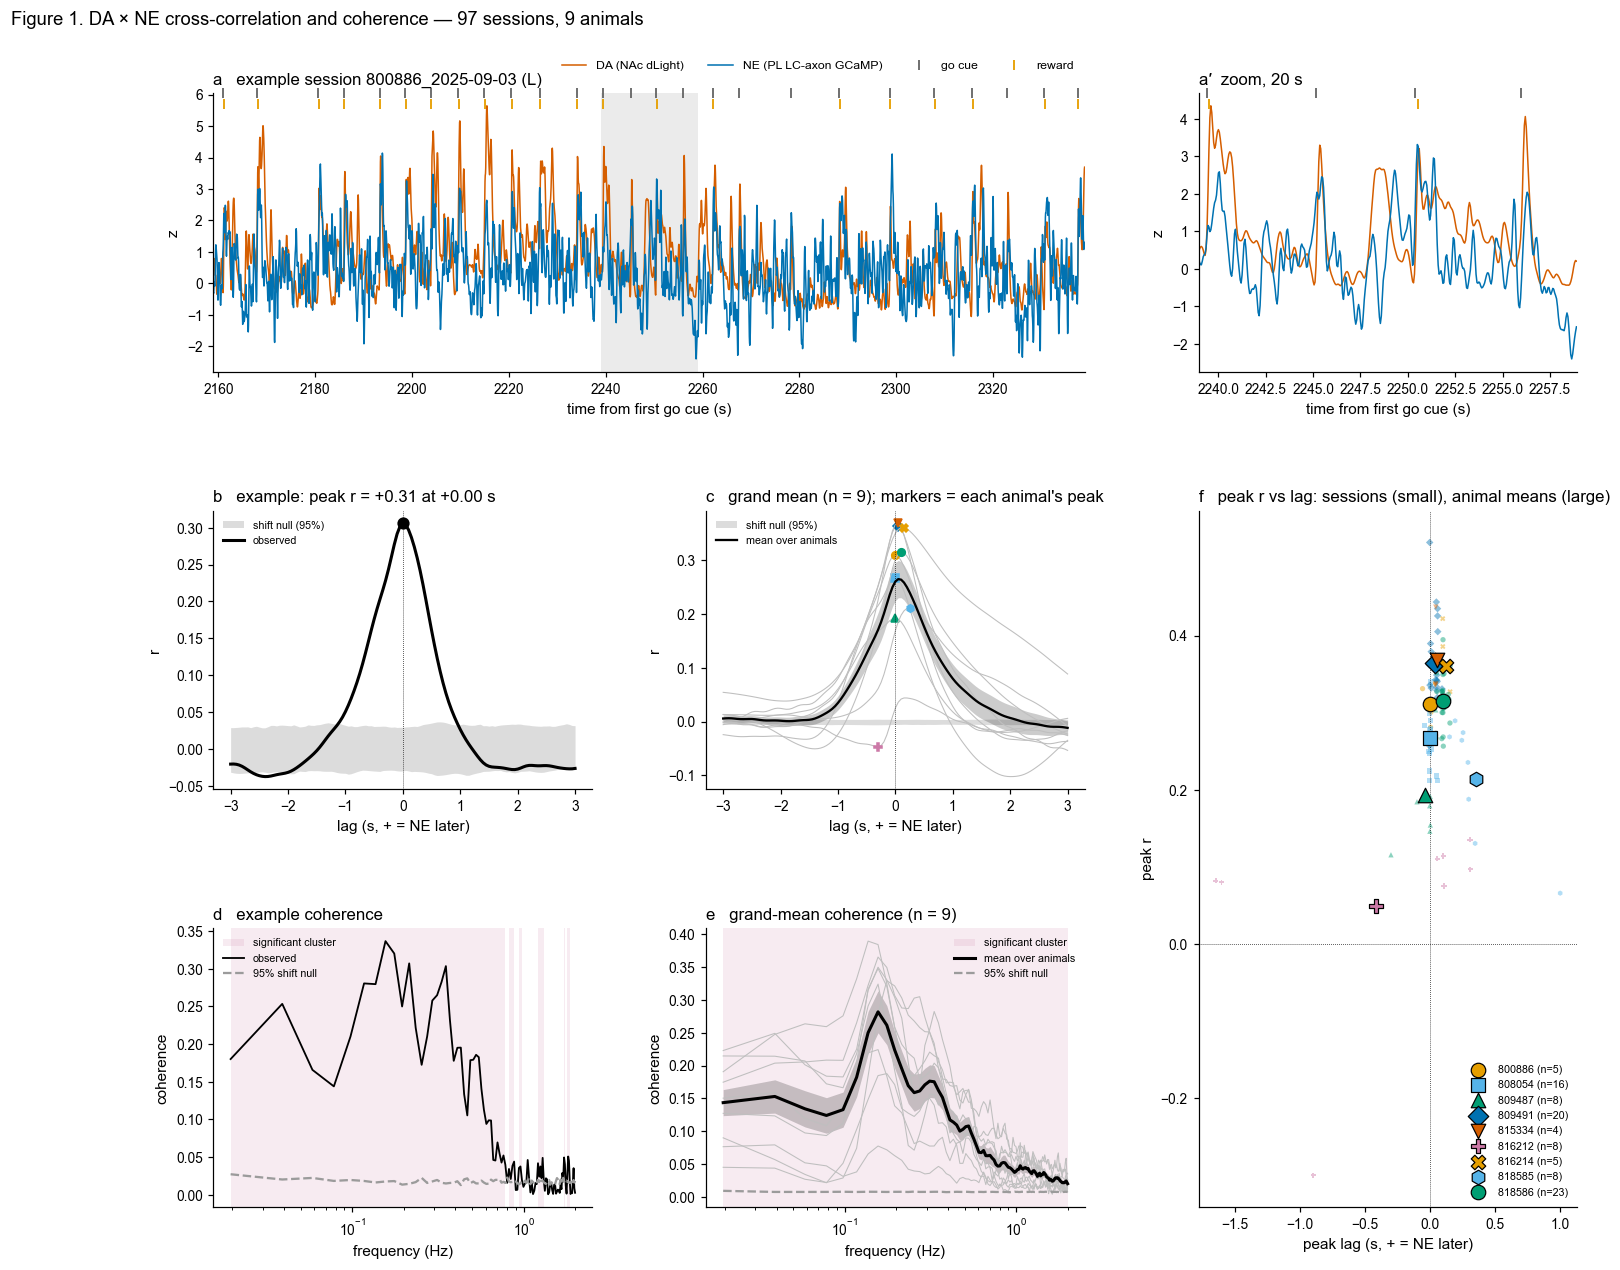

In [6]:
if EXAMPLE_SESSION is None:
    ex_i = int(np.argmin(np.abs(xc_sess.peak_r - xc_sess.peak_r.median())))
else:
    ex_i = next(i for i, p in enumerate(pairs) if p["session"] == EXAMPLE_SESSION)
ex = pairs[ex_i]
ex_row = xc_sess.iloc[ex_i]
ex_clusters, ex_thr = cluster_test(ex["coh"][IN_F], ex["coh_null"][:, IN_F], f_coh[IN_F])
t_mid = 0.5 * (ex["t"][0] + ex["t"][-1])
win_a = (t_mid - EXAMPLE_WINDOW_S / 2, t_mid + EXAMPLE_WINDOW_S / 2)
win_z = (t_mid - EXAMPLE_ZOOM_S / 2, t_mid + EXAMPLE_ZOOM_S / 2)


def plot_traces(ax, p, win, shade=None, legend=False):
    m = (p["t"] >= win[0]) & (p["t"] < win[1])
    for s in ("da", "ne"):
        ax.plot(p["t"][m], p["z"][s][m], color=SIG_COLOR[s], lw=1.0, label=SIG_LABEL[s])
    tr = p["trials"]
    for col, sel, c, lab in ((CUE, np.ones(len(tr), bool), PALETTE["neutral"], "go cue"),
                             ("reward_outcome_time_in_session", tr["earned_reward"].astype(bool),
                              OUT_COLOR["rewarded"], "reward")):
        t = tr.loc[sel, col].dropna().to_numpy()
        t = t[(t >= win[0]) & (t < win[1])]
        ax.plot(t, np.full(len(t), 1.0 if lab == "go cue" else 0.96), "|", color=c, ms=7, mew=1.2,
                label=lab, transform=ax.get_xaxis_transform(), clip_on=False)
    if shade:
        ax.axvspan(*shade, color=NULL_COLOR, alpha=0.2, lw=0)
    ax.set_xlim(win)
    ax.set_xlabel("time from first go cue (s)")
    ax.set_ylabel("z")
    if legend:
        ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.04), ncol=4, frameon=False, fontsize=8)
    style_ax(ax)


fig = plt.figure(figsize=(16, 12.5))
gs = GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.3, top=0.92)

ax = fig.add_subplot(gs[0, :2])
plot_traces(ax, ex, win_a, shade=win_z, legend=True)
ax.set_title(f"a   example session {ex['session']} ({ex['side']})", loc="left")
ax = fig.add_subplot(gs[0, 2])
plot_traces(ax, ex, win_z)
ax.set_title(f"a′  zoom, {EXAMPLE_ZOOM_S:.0f} s", loc="left")

ax = fig.add_subplot(gs[1, 0])
lo, hi = np.percentile(ex["xc_null"], [2.5, 97.5], axis=0)
ax.fill_between(LAGS, lo, hi, color=NULL_COLOR, alpha=0.35, lw=0, label="shift null (95%)")
ax.plot(LAGS, ex["xc"], color=TOTAL_COLOR, lw=2, label="observed")
ax.plot(ex_row.peak_lag, ex_row.peak_r, "o", color=TOTAL_COLOR, ms=7)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("lag (s, + = NE later)")
ax.set_ylabel("r")
ax.set_title(f"b   example: peak r = {ex_row.peak_r:+.2f} at {ex_row.peak_lag:+.2f} s", loc="left")
ax.legend(fontsize=7, loc="upper left")
style_ax(ax)

ax = fig.add_subplot(gs[1, 1])
lo, hi = np.percentile(xc_null_grand, [2.5, 97.5], axis=0)
ax.fill_between(LAGS, lo, hi, color=NULL_COLOR, alpha=0.35, lw=0, label="shift null (95%)")
for i, c in enumerate(xc_animal):
    ax.plot(LAGS, c, color="0.75", lw=0.7)
    col, mk = ANIMAL_STYLE[SUBJECTS[i]]
    ax.plot(LAGS[k_an[i]], c[k_an[i]], mk, color=col, ms=5)
grand_trace(ax, list(xc_animal), LAGS, TOTAL_COLOR, "mean over animals")
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("lag (s, + = NE later)")
ax.set_ylabel("r")
ax.set_title(f"c   grand mean (n = {N_ANIMALS}); markers = each animal's peak", loc="left")
ax.legend(fontsize=7, loc="upper left")
style_ax(ax)

ax = fig.add_subplot(gs[2, 0])
for i, c in enumerate(ex_clusters):
    ax.axvspan(c["lo_Hz"], c["hi_Hz"], color=CLUSTER_COLOR, alpha=0.15, lw=0,
               label="significant cluster" if i == 0 else None)
ax.semilogx(f_coh[IN_F], ex["coh"][IN_F], color=TOTAL_COLOR, lw=1.2, label="observed")
ax.semilogx(f_coh[IN_F], ex_thr, color=NULL_COLOR, lw=1.5, ls="--", label="95% shift null")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title("d   example coherence", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[2, 1])
for i, c in enumerate(coh_clusters):
    ax.axvspan(c["lo_Hz"], c["hi_Hz"], color=CLUSTER_COLOR, alpha=0.15, lw=0,
               label="significant cluster" if i == 0 else None)
for c in coh_animal:
    ax.semilogx(f_coh[IN_F], c[IN_F], color="0.75", lw=0.7)
m_, se_ = coh_animal.mean(0), coh_animal.std(0) / np.sqrt(N_ANIMALS)
ax.semilogx(f_coh[IN_F], m_[IN_F], color=TOTAL_COLOR, lw=2, label="mean over animals")
ax.fill_between(f_coh[IN_F], (m_ - se_)[IN_F], (m_ + se_)[IN_F], color=TOTAL_COLOR, alpha=0.2, lw=0)
ax.semilogx(f_coh[IN_F], coh_thr, color=NULL_COLOR, lw=1.5, ls="--", label="95% shift null")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title(f"e   grand-mean coherence (n = {N_ANIMALS})", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[1:, 2])
for subj in SUBJECTS:
    col, mk = ANIMAL_STYLE[subj]
    g = xc_sess[xc_sess.subject == subj]
    ax.scatter(g.peak_lag + (rng.random(len(g)) - 0.5) * 0.02, g.peak_r, s=12, color=col,
               marker=mk, alpha=0.45, edgecolor="none")
    a = xc_by_animal.loc[subj]
    ax.scatter(a.peak_lag, a.peak_r, s=90, color=col, marker=mk, edgecolor="k", lw=0.8,
               label=f"{subj} (n={len(g)})", zorder=3)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("peak lag (s, + = NE later)")
ax.set_ylabel("peak r")
ax.set_title("f   peak r vs lag: sessions (small), animal means (large)", loc="left")
ax.legend(fontsize=7, loc="lower right")
style_ax(ax)

fig.suptitle(f"Figure 1. DA × NE cross-correlation and coherence — {len(pairs)} sessions, "
             f"{N_ANIMALS} animals", x=0.01, ha="left")
save_fig(fig, "fip_07_fig1_xcorr_coherence", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## Figure 2. Large transients with and without a partner

From `fip_05` section 5. Transients are peaks of each z-scored trace found by
`scipy.signal.find_peaks` (`fc.detect_transients`, peaks at least `MIN_SEP_S` apart).
**Prominence** is a peak's height above the higher of the two troughs that separate it from
higher neighboring peaks, so a transient riding on a slow rise is scored by its own size. A
transient is **large** at prominence ≥ `LARGE_PROM` z. It has a **partner** if the other signal
has a transient of prominence ≥ `PARTNER_PROM` z within ±`MATCH_WIN_S` s, and is **solo**
otherwise. Chance is the matched fraction when the other signal's transient train is circularly
shifted; the chance-corrected coupling is (observed − chance) / (1 − chance).

Each transient also gets a task context from its peak time (`fc.label_context`), first rule that
applies: 0–1.5 s after a rewarded or an unrewarded outcome; 0–1.5 s after the go cue of an ignored
trial; a lickometer contact within ±1 s ("licking"); otherwise "quiet" (away from outcomes and
spout contacts, not measured stillness).

In [7]:
trans_rows, pair_rows = [], []
for p in pairs:
    z = p["z"]
    dur = len(z["da"]) / FS
    det = {s: fc.detect_transients(z[s], FS, prominence=PARTNER_PROM, min_sep_s=MIN_SEP_S)
           for s in ("da", "ne")}
    for s in ("da", "ne"):
        d = det[s]
        d["t"] = p["t0"] + d["i"] / FS
        d["context"] = fc.label_context(d["t"].to_numpy(), p)
        d["sig"], d["subject"], d["session"] = s, p["subject"], p["session"]
        trans_rows.append(d)
    for s, o in (("da", "ne"), ("ne", "da")):
        big = det[s][det[s]["prominence"] >= LARGE_PROM]
        idx, lag = fc.nearest_partner(big["t"].to_numpy(), det[o]["t"].to_numpy())
        null = fc.shift_coincidence_null(big["t"].to_numpy() - p["t0"],
                                         det[o]["t"].to_numpy() - p["t0"], dur, MATCH_WIN_S,
                                         n_null=100, rng=rng)
        pair_rows.append(pd.DataFrame(dict(
            subject=p["subject"], session=p["session"], sig=s, t=big["t"].values,
            prominence=big["prominence"].values, context=big["context"].values, lag=lag,
            partner_prom=det[o]["prominence"].to_numpy()[idx] if len(det[o]) else np.nan,
            null_frac=np.nanmean(null), dur=dur)))
transients = pd.concat(trans_rows, ignore_index=True)
paired = pd.concat(pair_rows, ignore_index=True)
paired["matched"] = paired["lag"].abs() <= MATCH_WIN_S
paired["solo"] = ~paired["matched"]

rows = []
for (subj, sess, sig), g in paired.groupby(["subject", "session", "sig"]):
    matched, chance = g["matched"].mean(), g["null_frac"].iloc[0]
    rows.append(dict(subject=subj, session=sess, sig=sig, rate_per_min=len(g) / g["dur"].iloc[0] * 60,
                     solo_frac=1 - matched, chance_solo=1 - chance,
                     coupling=(matched - chance) / (1 - chance)))
solo_animal = (pd.DataFrame(rows).groupby(["subject", "sig"])
               [["rate_per_min", "solo_frac", "chance_solo", "coupling"]].mean().unstack("sig"))
solo_animal.columns = [f"{a}_{b}" for a, b in solo_animal.columns]

paired["prom_bin"] = pd.cut(paired["prominence"], PROM_BINS, right=False)
size_curve = (paired.groupby(["subject", "sig", "prom_bin"], observed=True)["solo"].mean()
              .unstack("prom_bin"))
solo_by_ctx = (paired.groupby(["subject", "sig", "context"])["solo"].mean()
               .unstack("context").groupby(level="sig").mean())[CONTEXTS]

ETA_LAGS = np.arange(-2.0, 3.0 + 1e-9, 1 / FS)
eta = {}
for subj in SUBJECTS:
    acc = {}
    for p in (p for p in pairs if p["subject"] == subj):
        g = paired[paired.session == p["session"]]
        for s in ("da", "ne"):
            for solo in (True, False):
                t = g[(g.sig == s) & (g.solo == solo)]["t"].to_numpy()
                if len(t) < 3:
                    continue
                for o in ("da", "ne"):
                    acc.setdefault((s, solo, o), []).append(
                        np.nanmean(fc.peri_event(p["z"][o], p["t0"], FS, t, ETA_LAGS), 0))
    for k, v in acc.items():
        eta.setdefault(k, []).append(np.mean(v, 0))

print(solo_animal.mean().round(3).to_string())
print("\nsolo fraction by context (mean over animals):")
print(solo_by_ctx.round(2).to_string())

rate_per_min_da     8.722
rate_per_min_ne    20.315
solo_frac_da        0.174
solo_frac_ne        0.551
chance_solo_da      0.367
chance_solo_ne      0.718
coupling_da         0.520
coupling_ne         0.227

solo fraction by context (mean over animals):
context  rewarded  unrewarded  cue, no response  licking  quiet
sig                                                            
da           0.10        0.09              0.16     0.21   0.30
ne           0.18        0.26              0.44     0.57   0.76


In [8]:
# Panel a: a 20-s stretch of the Figure 1 example session holding a matched large DA transient,
# a matched large NE transient and a solo large NE transient, for the schematic.
SNIP_S = 20.0
g = paired[paired.session == ex["session"]]
best = None
for t0 in np.arange(ex["t"][0] + 5, ex["t"][-1] - SNIP_S, 2.0):
    w = g[(g.t >= t0 + 2) & (g.t < t0 + SNIP_S - 2)]
    ok = (((w.sig == "da") & w.matched).any() and ((w.sig == "ne") & w.solo).any()
          and ((w.sig == "ne") & w.matched).any())
    if ok and (best is None or abs(t0 - t_mid) < abs(best - t_mid)):
        best = t0
snip = (best, best + SNIP_S) if best is not None else win_z
print("schematic window:", np.round(snip, 1))


def plot_schematic(ax, p, win):
    m = (p["t"] >= win[0]) & (p["t"] < win[1])
    offset = {"da": 0.0, "ne": -6.0}        # NE drawn below DA
    tr_s = transients[(transients.session == p["session"])]
    pr_s = paired[paired.session == p["session"]]
    for s in ("da", "ne"):
        y = p["z"][s] + offset[s]
        ax.plot(p["t"][m], y[m], color=SIG_COLOR[s], lw=1.1, label=SIG_LABEL[s])
        d = tr_s[(tr_s.sig == s) & (tr_s.t >= win[0]) & (tr_s.t < win[1])]
        large = d[d.prominence >= LARGE_PROM]
        small = d[d.prominence < LARGE_PROM]
        ax.scatter(small.t, y[small.i.to_numpy()], s=28, facecolor="white", edgecolor=SIG_COLOR[s], lw=1.2,
                   zorder=4, label=f"{s.upper()} partner-level ({PARTNER_PROM:g}–{LARGE_PROM:g} z)")
        ax.scatter(large.t, y[large.i.to_numpy()], s=36, color=SIG_COLOR[s], zorder=4,
                   label=f"{s.upper()} large (≥ {LARGE_PROM:g} z)")
        for _, r in large.iterrows():                       # prominence: peak minus its base
            ax.plot([r.t, r.t], [y[int(r.i)] - r.prominence, y[int(r.i)]], color=SIG_COLOR[s], lw=1.6,
                    alpha=0.6)
        solo = pr_s[(pr_s.sig == s) & pr_s.solo & (pr_s.t >= win[0]) & (pr_s.t < win[1])]
        for _, r in solo.iterrows():
            ax.annotate("solo", (r.t, y[int(round((r.t - p["t0"]) * FS))]), xytext=(0, 10),
                        textcoords="offset points", ha="center", fontsize=8, color=SIG_COLOR[s])
    da_large = pr_s[(pr_s.sig == "da") & (pr_s.t >= win[0]) & (pr_s.t < win[1])]
    for k, (_, r) in enumerate(da_large.iterrows()):          # match window around each large DA peak
        ax.axvspan(r.t - MATCH_WIN_S, r.t + MATCH_WIN_S, color="0.85", alpha=0.6, lw=0, zorder=0,
                   label=f"±{MATCH_WIN_S:g} s match window" if k == 0 else None)
    if len(da_large):
        r = da_large.iloc[0]
        i = int(round((r.t - p["t0"]) * FS))
        ax.annotate("prominence", (r.t, p["z"]["da"][i] - r.prominence / 2), xytext=(8, 0),
                    textcoords="offset points", fontsize=8, va="center", color=SIG_COLOR["da"])
    ax.set_xlim(win)
    ax.set_yticks([])
    ax.set_xlabel("time from first go cue (s)")
    ax.set_ylabel("z (NE offset below DA)")
    ax.legend(fontsize=7, ncol=4, loc="lower right", bbox_to_anchor=(1.0, 1.02), frameon=False)
    style_ax(ax)

schematic window: [2246. 2266.]


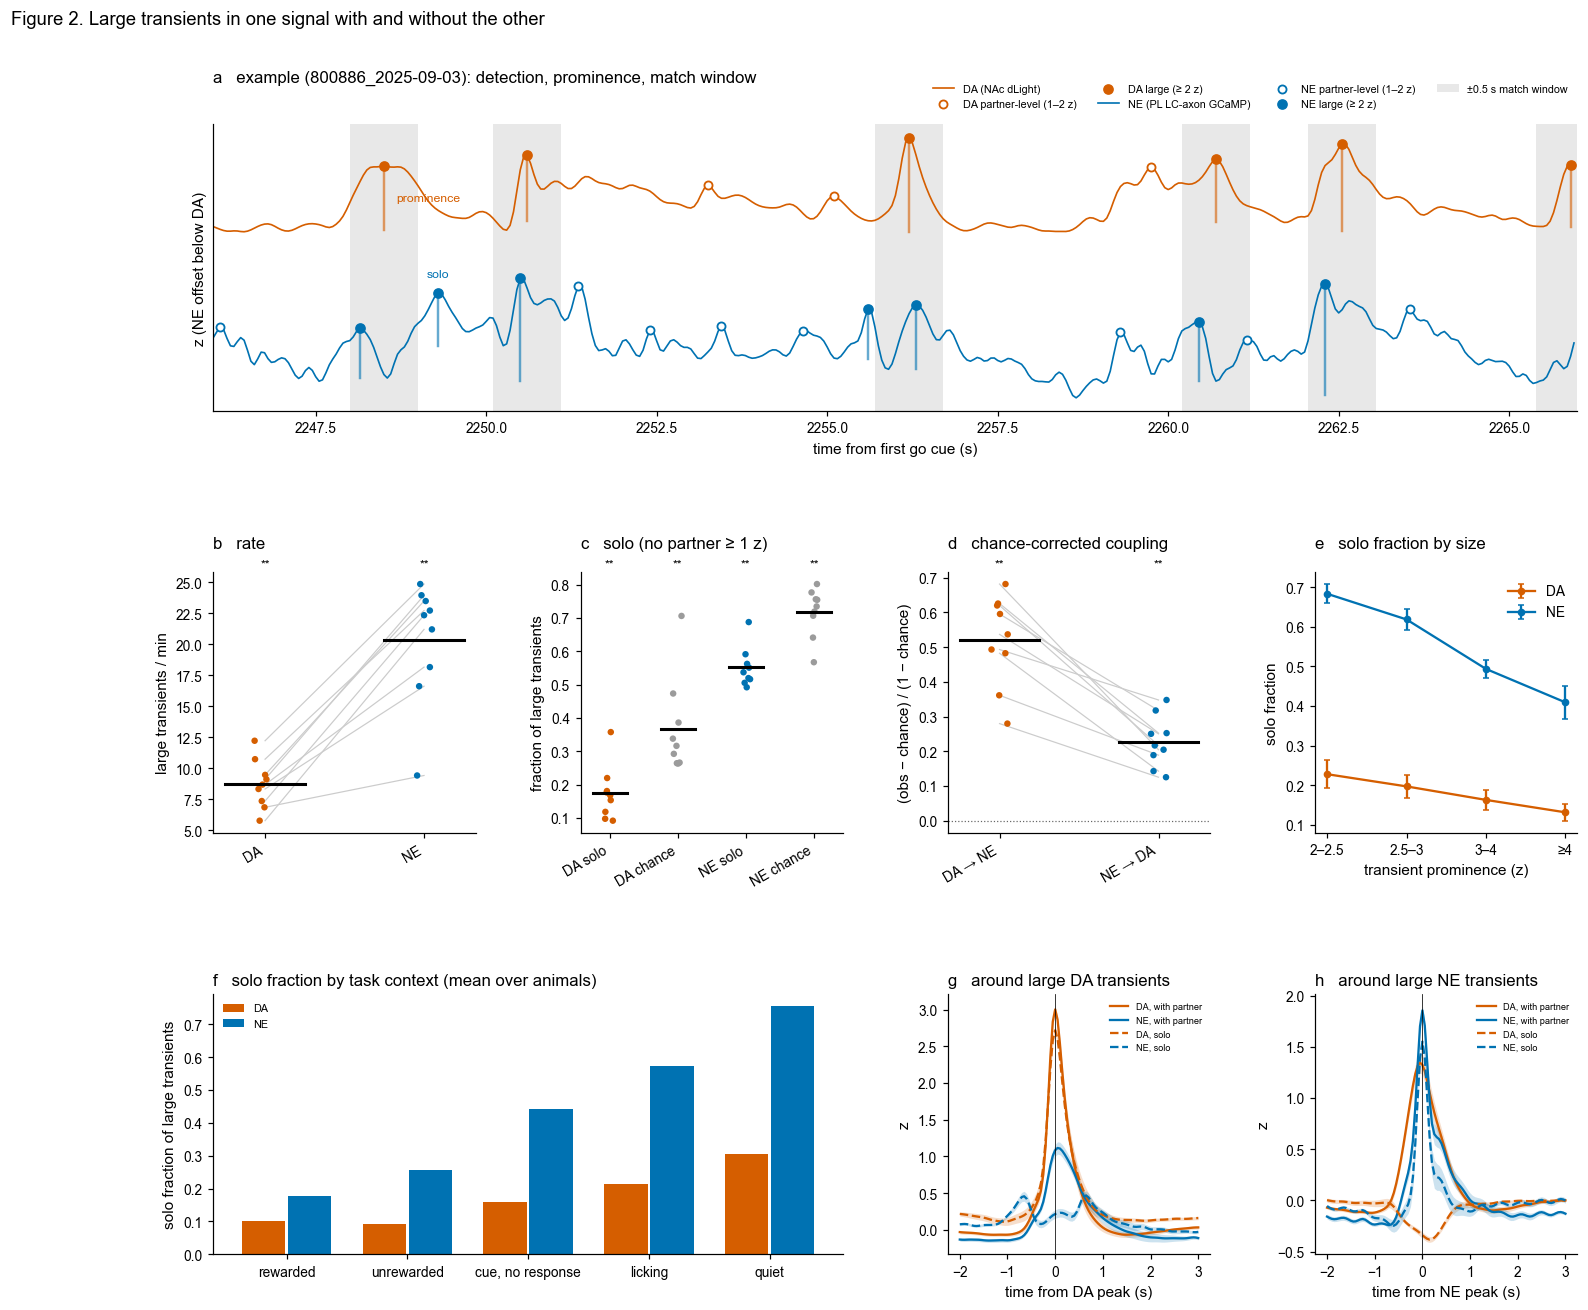

In [9]:
fig = plt.figure(figsize=(16, 13))
gs = GridSpec(3, 4, figure=fig, hspace=0.6, wspace=0.4, top=0.9, height_ratios=[1.1, 1, 1])

ax = fig.add_subplot(gs[0, :])
plot_schematic(ax, ex, snip)
ax.set_title(f"a   example ({ex['session']}): detection, prominence, match window", loc="left",
             pad=28)

ax = fig.add_subplot(gs[1, 0])
animal_strip(ax, solo_animal, ["rate_per_min_da", "rate_per_min_ne"], ["DA", "NE"],
             [SIG_COLOR["da"], SIG_COLOR["ne"]], "large transients / min", title="b   rate",
             zero=False)
ax = fig.add_subplot(gs[1, 1])
animal_strip(ax, solo_animal, ["solo_frac_da", "chance_solo_da", "solo_frac_ne", "chance_solo_ne"],
             ["DA solo", "DA chance", "NE solo", "NE chance"],
             [SIG_COLOR["da"], NULL_COLOR, SIG_COLOR["ne"], NULL_COLOR],
             "fraction of large transients", title=f"c   solo (no partner ≥ {PARTNER_PROM:g} z)",
             zero=False, connect=False)
ax = fig.add_subplot(gs[1, 2])
animal_strip(ax, solo_animal, ["coupling_da", "coupling_ne"], ["DA → NE", "NE → DA"],
             [SIG_COLOR["da"], SIG_COLOR["ne"]], "(obs − chance) / (1 − chance)",
             title="d   chance-corrected coupling")
ax = fig.add_subplot(gs[1, 3])
x = np.arange(len(PROM_BINS) - 1)
for s in ("da", "ne"):
    c = size_curve.xs(s, level="sig")
    ax.errorbar(x, c.mean(0), c.std(0) / np.sqrt(c.notna().sum(0)), color=SIG_COLOR[s],
                marker="o", ms=4, capsize=2, label=s.upper())
ax.set_xticks(x)
ax.set_xticklabels(["2–2.5", "2.5–3", "3–4", "≥4"])
ax.set_xlabel("transient prominence (z)")
ax.set_ylabel("solo fraction")
ax.set_title("e   solo fraction by size", loc="left", pad=16)
ax.legend()
style_ax(ax)

ax = fig.add_subplot(gs[2, 0:2])
xx = np.arange(len(CONTEXTS))
for k, s in enumerate(("da", "ne")):
    ax.bar(xx + (k - 0.5) * 0.38, solo_by_ctx.loc[s], width=0.36, color=SIG_COLOR[s],
           label=f"{s.upper()}")
ax.set_xticks(xx)
ax.set_xticklabels(CONTEXTS)
ax.set_ylabel("solo fraction of large transients")
ax.set_title("f   solo fraction by task context (mean over animals)", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

for k, (s, title) in enumerate((("da", "g   around large DA transients"),
                                ("ne", "h   around large NE transients"))):
    ax = fig.add_subplot(gs[2, 2 + k])
    for solo, ls in ((False, "-"), (True, "--")):
        for o in ("da", "ne"):
            if (s, solo, o) in eta:
                grand_trace(ax, eta[(s, solo, o)], ETA_LAGS, SIG_COLOR[o],
                            f"{o.upper()}, {'solo' if solo else 'with partner'}", ls=ls)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel(f"time from {s.upper()} peak (s)")
    ax.set_ylabel("z")
    ax.set_title(title, loc="left")
    ax.legend(fontsize=6)
    style_ax(ax)

fig.suptitle("Figure 2. Large transients in one signal with and without the other", x=0.01,
             ha="left")
save_fig(fig, "fip_07_fig2_transients", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## Figure 3. Task-aligned responses and their trial-by-trial coupling

Everything here runs through Rachel's pipeline on `data_z_norm`. Per session and signal:

- **Response size**: `trial_metrics.get_average_signal_window` (her `add_AUC_and_rpe_slope` step),
  the mean `data_z_norm` in each window after the choice. With her window it reproduces the
  `avg_data_z_norm_<channel>_choice_time` column her pipeline stored.
- **Aligned traces**: `alignment.event_triggered_response`, choice-aligned, one row per responded
  trial.
- **Peak latency**: the same function, go-cue-aligned; the latency is the time of the maximum
  0–1.5 s after the cue. It counts only if the maximum is ≥ `MIN_PEAK_Z` above the pre-cue baseline
  and not on the window's first or last sample, in both signals.
- **RPE groups** (3b): Rachel's `Qch-binned3`, outcome × Q_chosen in thirds. Within an outcome RPE
  is 1 − Q_chosen (rewarded) or −Q_chosen (unrewarded), so each group is an RPE range inside one
  outcome. Two sessions whose model fit leaves RPE nearly constant (`MIN_RPE_SD`, from `fip_05`) and
  trials before a session's first reward (Q still at its initial 0, `fip_06`) are left out of 3b.

Trials: responded, without extra (unearned) water. The correlations (3c, 3d) are per session across
trials, averaged within animal: **total** uses all trials, **within rewarded / unrewarded** only
trials of that outcome. Loading and window means take about 15 minutes the first time and are
cached.

In [10]:
def session_trial_table(row):
    """Rachel-pipeline per-trial measures and choice-aligned traces for one session."""
    nwb = dummy_nwb.load(row.path, load_fip=True)
    tr = nwb.df_trials.copy()
    resp = tr[(tr["animal_response"] < 2) & tr[ALIGN].notna() & tr[CUE].notna()].sort_values(ALIGN)
    psth = {}
    for sig, ch in (("da", row.da_event), ("ne", row.ne_event)):
        for w, (a, b) in WINDOWS.items():
            col = f"{sig}_{w}"
            out = trial_metrics.get_average_signal_window(nwb, ALIGN, [a, b], ch,
                                                          data_column=DATA_COL, output_col=col)
            tr = tr.merge(out[["trial", col]], on="trial", how="left")
        d = nwb.df_fip.query("event == @ch")
        # choice-aligned traces (3a, 3b)
        etr = alignment.event_triggered_response(d, "timestamps", DATA_COL, resp[ALIGN].to_numpy(),
                                                 t_start=PSTH_T[0], t_end=PSTH_T[1],
                                                 output_sampling_rate=FS, censor=True)
        M = etr.pivot(index="event_number", columns="time", values=DATA_COL)
        psth[sig] = M.reindex(range(len(resp))).to_numpy(np.float32)
        psth_t = M.columns.to_numpy()
        # go-cue-aligned peak latency (3d)
        cue_times = resp[CUE].to_numpy()
        order = np.argsort(cue_times)
        etr = alignment.event_triggered_response(d, "timestamps", DATA_COL, cue_times[order],
                                                 t_start=LATENCY_WIN[0], t_end=LATENCY_WIN[1],
                                                 output_sampling_rate=FS, censor=True,
                                                 include_endpoint=False)
        C = etr.pivot(index="event_number", columns="time", values=DATA_COL)
        C = C.reindex(range(len(resp))).to_numpy()
        C_trial = np.full_like(C, np.nan)
        C_trial[order] = C                           # back to choice order
        ok = np.isfinite(C_trial).all(1)
        k = np.full(len(resp), -1)
        k[ok] = np.argmax(C_trial[ok], 1)
        lat_t = etr["time"].drop_duplicates().sort_values().to_numpy()
        lat = pd.Series(np.where(k >= 0, lat_t[np.clip(k, 0, None)], np.nan), index=resp["trial"])
        peak = pd.Series(np.where(ok, np.nanmax(np.where(ok[:, None], C_trial, 0), 1), np.nan),
                         index=resp["trial"])
        edge = pd.Series((k == 0) | (k == len(lat_t) - 1), index=resp["trial"])
        tr[f"{sig}_lat"] = tr["trial"].map(lat)
        tr[f"{sig}_peak"] = tr["trial"].map(peak)
        tr[f"{sig}_edge"] = tr["trial"].map(edge)
        stored = f"avg_{DATA_COL}_{ch}_choice_time"
        tr[f"{sig}_stored"] = tr[stored] if stored in tr else np.nan
    keep = ["trial", "animal_response", "earned_reward", "extra_reward", "RPE_earned", "Q_chosen",
            "Qch-binned3", "response_time", ALIGN] + [c for c in tr if c[:3] in ("da_", "ne_")]
    return dict(subject=row.subject, session=row.session, trials=tr[keep],
                psth=psth, psth_trial=resp["trial"].to_numpy(), psth_t=psth_t)


key = (tuple(kept["path"]), tuple(WINDOWS.items()), PSTH_T, LATENCY_WIN, DATA_COL, FS)
if os.path.exists(TRIAL_CACHE) and pickle.load(open(TRIAL_CACHE, "rb"))["key"] == key:
    sess_tables = pickle.load(open(TRIAL_CACHE, "rb"))["tables"]
    print(f"loaded {len(sess_tables)} sessions from {TRIAL_CACHE}")
else:
    sess_tables = []
    for i, row in enumerate(kept.itertuples()):
        sess_tables.append(session_trial_table(row))
        if (i + 1) % 10 == 0:
            print(f"  {i + 1} / {len(kept)}")
    os.makedirs(os.path.dirname(os.path.abspath(TRIAL_CACHE)), exist_ok=True)
    pickle.dump(dict(key=key, tables=sess_tables), open(TRIAL_CACHE, "wb"))
PSTH_TIME = sess_tables[0]["psth_t"]

  10 / 97


  20 / 97


  30 / 97


  40 / 97


  50 / 97


  60 / 97


  70 / 97


  80 / 97


  90 / 97


In [11]:
T = pd.concat([s["trials"].assign(subject=s["subject"], session=s["session"]) for s in sess_tables],
              ignore_index=True)
T["responded"] = T["animal_response"] < 2
T["extra"] = T["extra_reward"].fillna(0).astype(bool)
T["rewarded"] = T["earned_reward"].fillna(0).astype(bool) & T["responded"]
trials = T[T.responded & ~T.extra].copy()

# 3b exclusions (fip_05, fip_06)
rpe_sd = trials.groupby(["session", "rewarded"])["RPE_earned"].std().unstack().min(axis=1)
FLAT_RPE = set(rpe_sd.index[rpe_sd < MIN_RPE_SD])
trials["before_first_reward"] = (trials.groupby("session")["rewarded"]
                                 .transform(lambda r: r.cumsum().shift(fill_value=0) == 0))
trials["qbin"] = trials["Qch-binned3"].astype(str).str.extract(r"\((Qch [\d.]+)\)")[0]
print(f"{len(trials)} responded trials without extra water; "
      f"{T.responded.sum() - len(trials)} with extra water left out")
print("left out of 3b: flat-RPE sessions", sorted(FLAT_RPE),
      f"and {int(trials.before_first_reward.sum())} trials before the first reward")

# Rachel's window, recomputed with her function, against the column her pipeline stored
for sig in ("da", "ne"):
    d = trials[[f"{sig}_rachel", f"{sig}_stored"]].dropna()
    print(f"{sig}: {len(d)} trials, max |recomputed − stored| = "
          f"{(d[f'{sig}_rachel'] - d[f'{sig}_stored']).abs().max():.2g}")

43903 responded trials without extra water; 393 with extra water left out
left out of 3b: flat-RPE sessions ['816212_2025-12-10', '818586_2026-01-05'] and 238 trials before the first reward
da: 43794 trials, max |recomputed − stored| = 0
ne: 43794 trials, max |recomputed − stored| = 0


In [12]:
# 3a / 3b: session mean trace per group, then per animal
def group_traces(select):
    """{(sig, group): [per-animal mean trace]} for groups given by select(trials_of_session)."""
    out = {}
    for subj in SUBJECTS:
        acc = {}
        for s in (s for s in sess_tables if s["subject"] == subj):
            t = trials[trials.session == s["session"]].set_index("trial")
            row_of = {tr: i for i, tr in enumerate(s["psth_trial"])}
            for grp, trial_ids in select(t).items():
                rows = [row_of[x] for x in trial_ids if x in row_of]
                if len(rows) < 3:
                    continue
                for sig in ("da", "ne"):
                    acc.setdefault((sig, grp), []).append(np.nanmean(s["psth"][sig][rows], 0))
        for k, v in acc.items():
            out.setdefault(k, []).append(np.mean(v, 0))
    return out


by_outcome = group_traces(lambda t: {"rewarded": t.index[t.rewarded],
                                     "unrewarded": t.index[~t.rewarded]})


def rpe_groups(t):
    if t.empty or t["session"].iloc[0] in FLAT_RPE:
        return {}
    t = t[~t.before_first_reward]
    return {(out, q): t.index[(t.rewarded == (out == "rewarded")) & (t.qbin == q)]
            for out in ("rewarded", "unrewarded") for q in QCH_BINS}


by_rpe = group_traces(rpe_groups)
# RPE range of each Q_chosen third within an outcome, ordered from low to high RPE
RPE_ORDER = {"rewarded": ["Qch 0.66", "Qch 0.33", "Qch 0"],        # RPE = 1 − Q
             "unrewarded": ["Qch 0.66", "Qch 0.33", "Qch 0"]}      # RPE = −Q
RPE_RANGE = {("rewarded", "Qch 0.66"): "RPE 0–0.33", ("rewarded", "Qch 0.33"): "RPE 0.33–0.67",
             ("rewarded", "Qch 0"): "RPE 0.67–1", ("unrewarded", "Qch 0.66"): "RPE −1 to −0.67",
             ("unrewarded", "Qch 0.33"): "RPE −0.67 to −0.33", ("unrewarded", "Qch 0"): "RPE −0.33–0"}
print({k: len(v) for k, v in by_rpe.items()})

{('da', ('rewarded', 'Qch 0')): 9, ('ne', ('rewarded', 'Qch 0')): 9, ('da', ('rewarded', 'Qch 0.33')): 9, ('ne', ('rewarded', 'Qch 0.33')): 9, ('da', ('rewarded', 'Qch 0.66')): 9, ('ne', ('rewarded', 'Qch 0.66')): 9, ('da', ('unrewarded', 'Qch 0')): 9, ('ne', ('unrewarded', 'Qch 0')): 9, ('da', ('unrewarded', 'Qch 0.33')): 9, ('ne', ('unrewarded', 'Qch 0.33')): 9, ('da', ('unrewarded', 'Qch 0.66')): 9, ('ne', ('unrewarded', 'Qch 0.66')): 9}


In [13]:
# 3c: response size correlated across trials, per window
rows = []
for (subj, sess), g in trials.groupby(["subject", "session"]):
    d = dict(subject=subj, session=sess)
    for w in WINDOWS:
        d[f"total_{w}"] = sess_corr(g, f"da_{w}", f"ne_{w}")
        d[f"rewarded_{w}"] = sess_corr(g[g.rewarded], f"da_{w}", f"ne_{w}")
        d[f"unrewarded_{w}"] = sess_corr(g[~g.rewarded], f"da_{w}", f"ne_{w}")
    rows.append(d)
size_corr = fc.animal_means(pd.DataFrame(rows), [f"{k}_{w}" for w in WINDOWS
                                                 for k in ("total", "rewarded", "unrewarded")],
                            by_session=False)
tbl = []
for c in size_corr:
    k, w = c.rsplit("_", 1)
    m, pv, n = fc.wilcoxon_animals(size_corr[c])
    tbl.append(dict(window=WINDOW_LABEL[w], trials=k, mean_r=m, p=pv,
                    n_positive=f"{int((size_corr[c] > 0).sum())}/{n}"))
pd.DataFrame(tbl).set_index(["window", "trials"]).round(3)

mean_r      p n_positive
window          trials                              
Rachel 0.33–1 s total        0.349  0.004        9/9
                rewarded     0.205  0.008        8/9
                unrewarded   0.153  0.020        7/9
early 0–0.5 s   total        0.192  0.004        9/9
                rewarded     0.165  0.004        9/9
                unrewarded   0.123  0.008        8/9
late 0.5–2 s    total        0.321  0.008        8/9
                rewarded     0.143  0.012        8/9
                unrewarded   0.121  0.074        7/9
full 0–2 s      total        0.314  0.004        9/9
                rewarded     0.139  0.020        8/9
                unrewarded   0.126  0.055        7/9

In [14]:
# 3d: peak latency after the go cue, correlated across trials
lat_all = trials.dropna(subset=["da_lat", "ne_lat"]).copy()
lat_all["both_ok"] = ~(lat_all.da_edge.astype(bool) | lat_all.ne_edge.astype(bool)
                       | (lat_all.da_peak < MIN_PEAK_Z) | (lat_all.ne_peak < MIN_PEAK_Z))
print("fraction of trials with a latency in both signals:")
print(lat_all.groupby("rewarded")["both_ok"].mean().rename(index={True: "rewarded",
                                                                  False: "unrewarded"}).round(3))
lat = lat_all[lat_all.both_ok]
rows = []
for (subj, sess), g in lat.groupby(["subject", "session"]):
    d = dict(subject=subj, session=sess,
             total=sess_corr(g, "da_lat", "ne_lat", "spearman"),
             rewarded=sess_corr(g[g.rewarded], "da_lat", "ne_lat", "spearman"),
             unrewarded=sess_corr(g[~g.rewarded], "da_lat", "ne_lat", "spearman"))
    for out, m in (("rew", g.rewarded), ("unrew", ~g.rewarded)):
        for sig in ("da", "ne"):
            d[f"{sig}_lat_{out}"] = g.loc[m, f"{sig}_lat"].median()
    rows.append(d)
lat_corr = fc.animal_means(pd.DataFrame(rows), ["total", "rewarded", "unrewarded", "da_lat_rew",
                                                "ne_lat_rew", "da_lat_unrew", "ne_lat_unrew"],
                           by_session=False)
lat_corr["ne_minus_da_rew"] = lat_corr.ne_lat_rew - lat_corr.da_lat_rew
lat_corr["ne_minus_da_unrew"] = lat_corr.ne_lat_unrew - lat_corr.da_lat_unrew
for c in lat_corr:
    m, pv, n = fc.wilcoxon_animals(lat_corr[c])
    print(f"{c:18s} mean {m:+.3f}  p = {pv:.4f}  (n = {n})")

fraction of trials with a latency in both signals:
rewarded
unrewarded    0.765
rewarded      0.875
Name: both_ok, dtype: float64


total              mean +0.218  p = 0.0039  (n = 9)
rewarded           mean +0.100  p = 0.0039  (n = 9)
unrewarded         mean +0.042  p = 0.0039  (n = 9)
da_lat_rew         mean +0.545  p = 0.0039  (n = 9)
ne_lat_rew         mean +0.563  p = 0.0039  (n = 9)
da_lat_unrew       mean +0.243  p = 0.0039  (n = 9)
ne_lat_unrew       mean +0.400  p = 0.0039  (n = 9)
ne_minus_da_rew    mean +0.017  p = 0.7344  (n = 9)
ne_minus_da_unrew  mean +0.157  p = 0.0039  (n = 9)


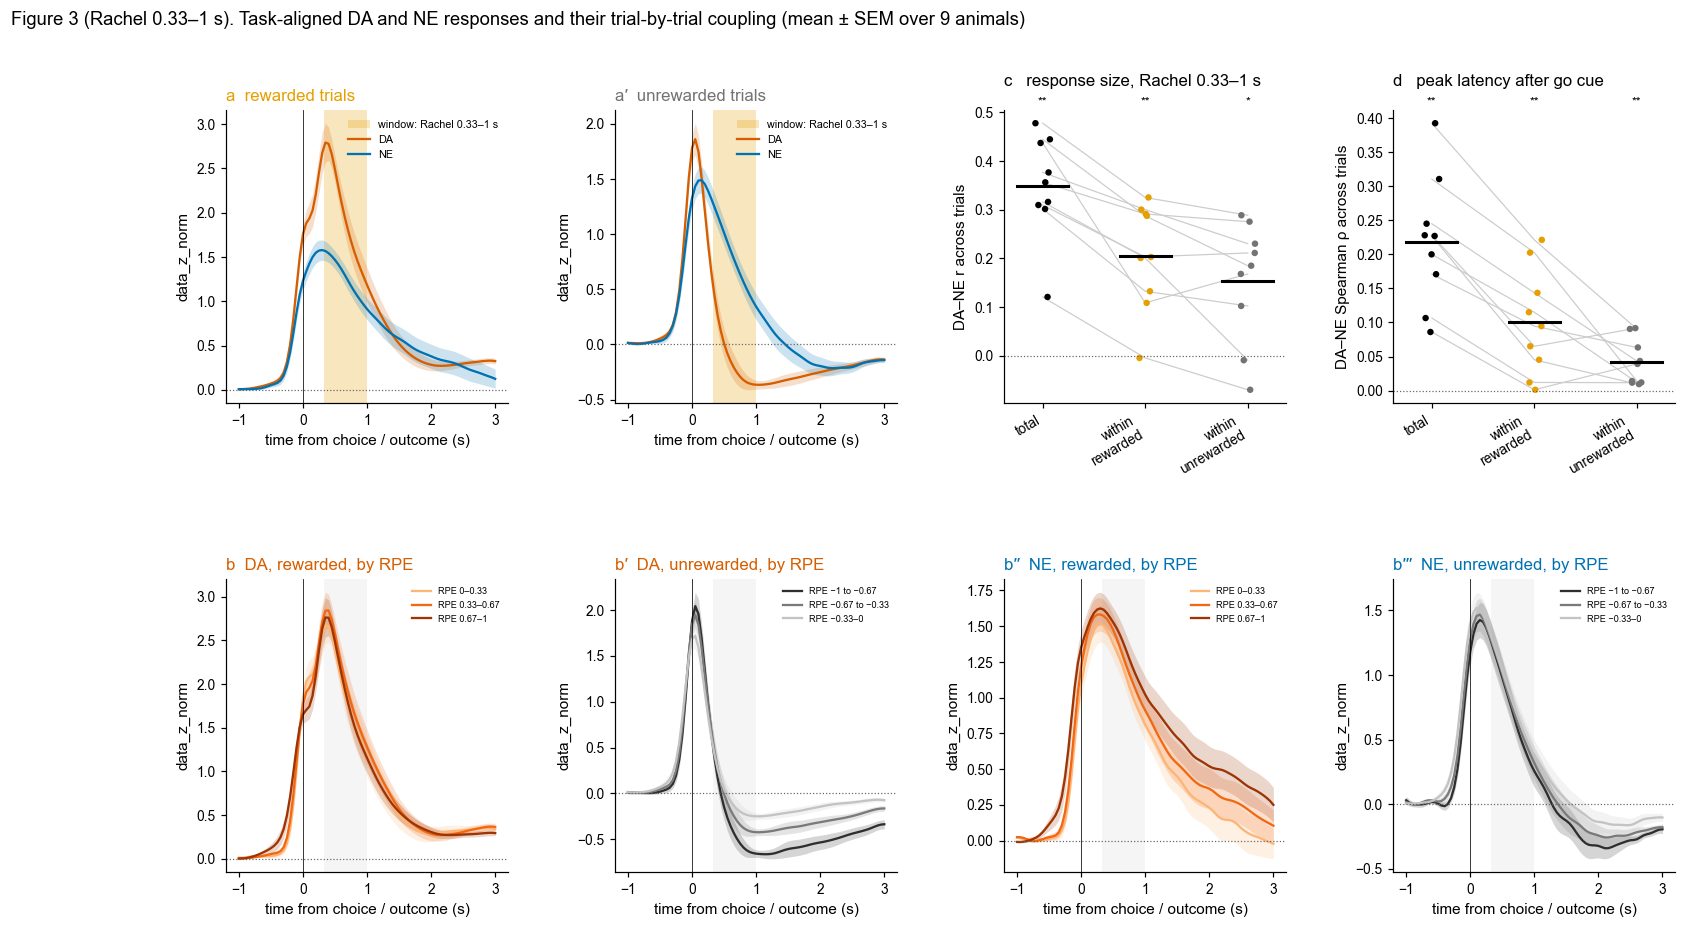

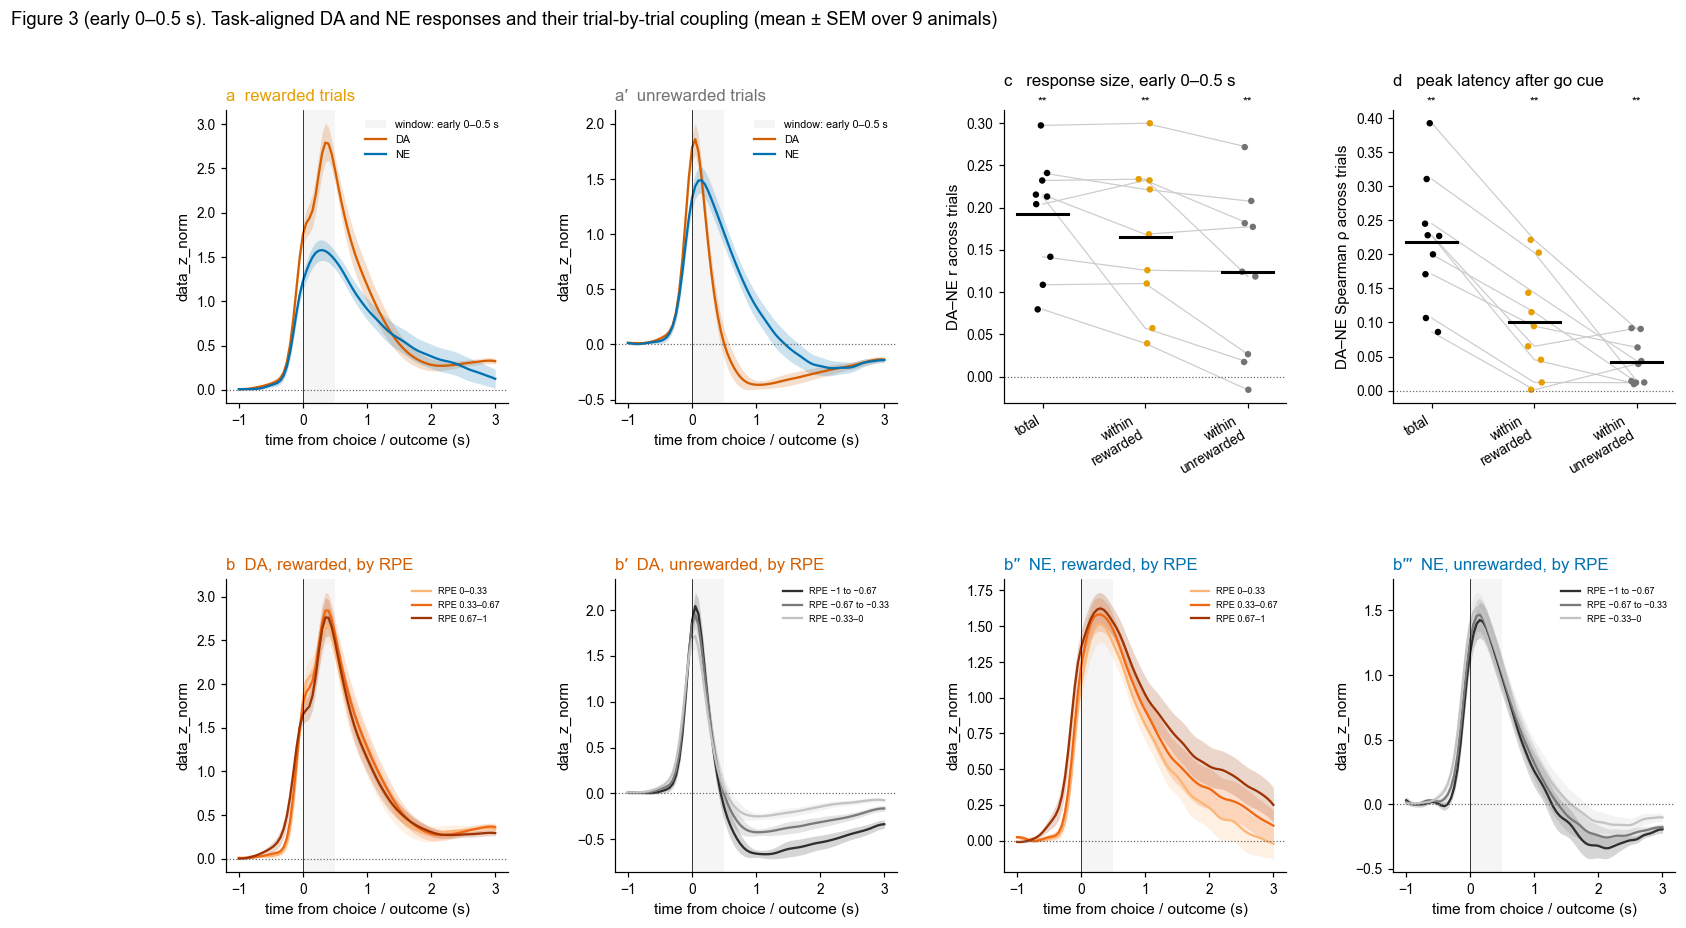

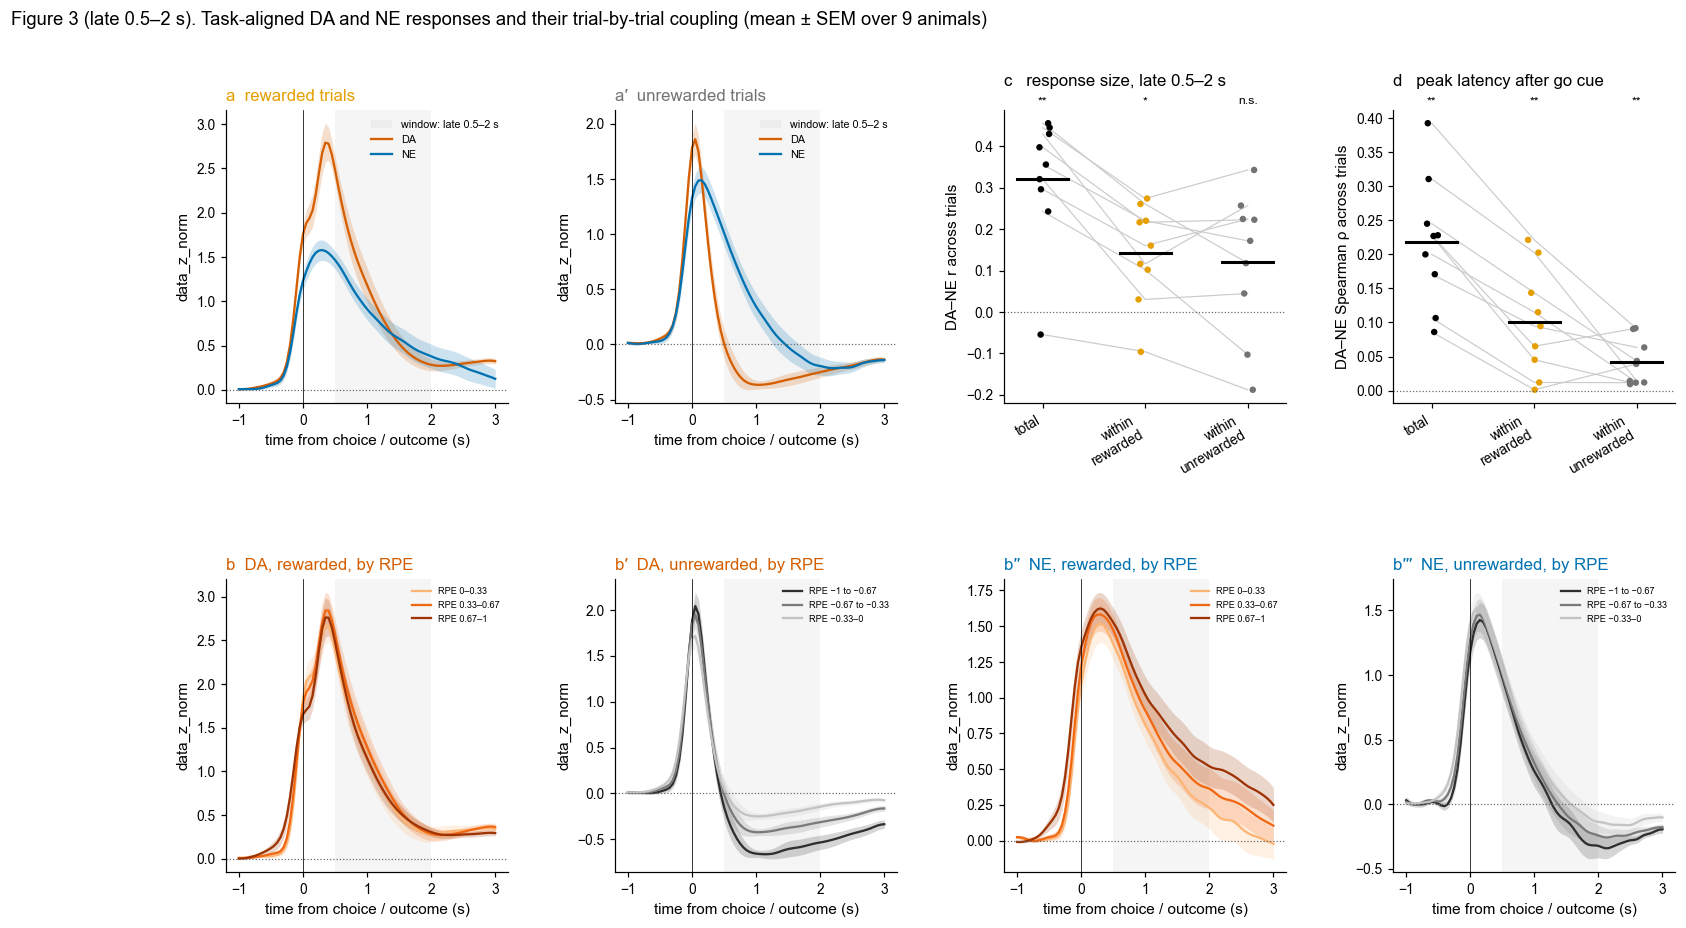

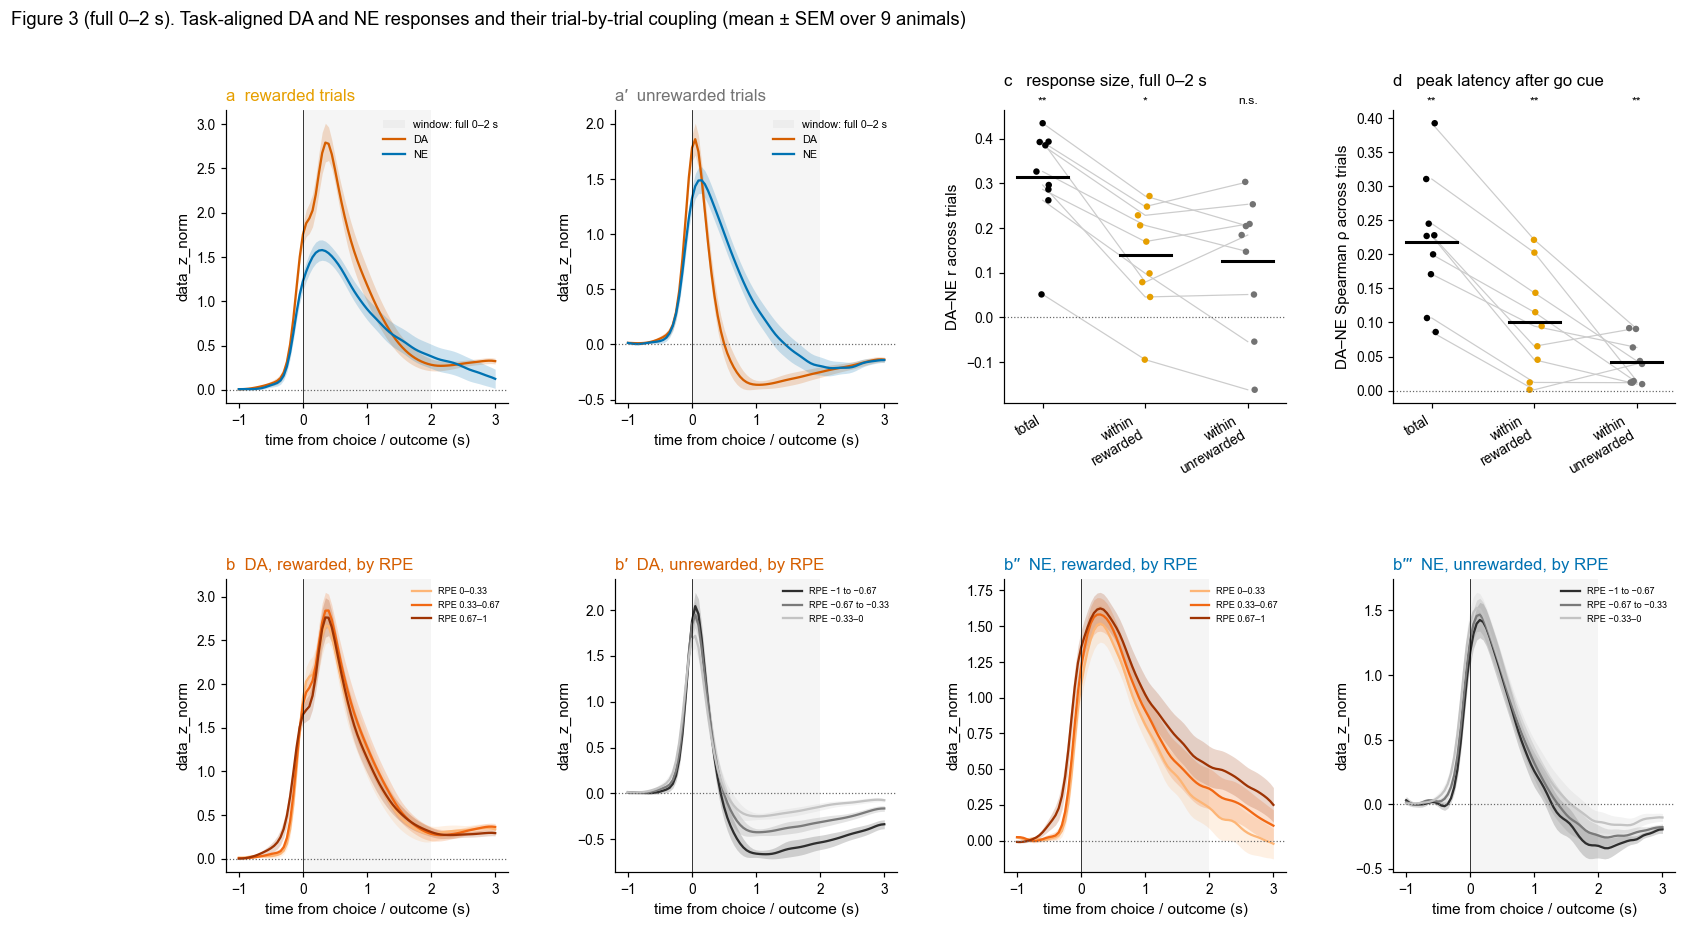

In [15]:
def make_fig3(w):
    a, b = WINDOWS[w]
    fig = plt.figure(figsize=(17, 9))
    gs = GridSpec(2, 4, figure=fig, hspace=0.6, wspace=0.38, top=0.88)

    for j, out in enumerate(("rewarded", "unrewarded")):
        ax = fig.add_subplot(gs[0, j])
        ax.axvspan(a, b, color=OUT_COLOR["rewarded"] if w == "rachel" else "0.85", alpha=0.25, lw=0,
                   label=f"window: {WINDOW_LABEL[w]}")
        for sig in ("da", "ne"):
            grand_trace(ax, by_outcome[(sig, out)], PSTH_TIME, SIG_COLOR[sig], sig.upper())
        ax.axvline(0, color="k", lw=0.5)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.set_xlabel("time from choice / outcome (s)")
        ax.set_ylabel("data_z_norm")
        ax.set_title(f"{'a' if j == 0 else 'a′'}  {out} trials", loc="left", color=OUT_COLOR[out])
        ax.legend(fontsize=7)
        style_ax(ax)

    ax = fig.add_subplot(gs[0, 2])
    animal_strip(ax, size_corr, [f"{k}_{w}" for k in ("total", "rewarded", "unrewarded")],
                 ["total", "within\nrewarded", "within\nunrewarded"],
                 [TOTAL_COLOR, OUT_COLOR["rewarded"], OUT_COLOR["unrewarded"]],
                 "DA–NE r across trials", title=f"c   response size, {WINDOW_LABEL[w]}")
    ax = fig.add_subplot(gs[0, 3])
    animal_strip(ax, lat_corr, ["total", "rewarded", "unrewarded"],
                 ["total", "within\nrewarded", "within\nunrewarded"],
                 [TOTAL_COLOR, OUT_COLOR["rewarded"], OUT_COLOR["unrewarded"]],
                 "DA–NE Spearman ρ across trials", title="d   peak latency after go cue")

    for j, (sig, out) in enumerate([(s, o) for s in ("da", "ne") for o in ("rewarded", "unrewarded")]):
        ax = fig.add_subplot(gs[1, j])
        ax.axvspan(a, b, color="0.85", alpha=0.25, lw=0)
        for k, q in enumerate(RPE_ORDER[out]):
            if (sig, (out, q)) in by_rpe:
                grand_trace(ax, by_rpe[(sig, (out, q))], PSTH_TIME, RPE_BIN_COLOR[out][k],
                            RPE_RANGE[(out, q)])
        ax.axvline(0, color="k", lw=0.5)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.set_xlabel("time from choice / outcome (s)")
        ax.set_ylabel("data_z_norm")
        ax.set_title(f"b{'′' * j}  {sig.upper()}, {out}, by RPE", loc="left", color=SIG_COLOR[sig])
        ax.legend(fontsize=6)
        style_ax(ax)
    fig.suptitle(f"Figure 3 ({WINDOW_LABEL[w]}). Task-aligned DA and NE responses and their "
                 f"trial-by-trial coupling (mean ± SEM over {N_ANIMALS} animals)", x=0.01, ha="left")
    save_fig(fig, f"fip_07_fig3_task_{w}", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()


for w in WINDOWS:
    make_fig3(w)

## Numbers behind each figure

One row per headline measure: mean over animals, Wilcoxon p against zero (or against the shift null
where stated), and how many animals are positive.

In [16]:
def row(fig, measure, values):
    v = np.asarray(values, float)
    m, pv, n = fc.wilcoxon_animals(v)
    return dict(figure=fig, measure=measure, mean=round(m, 3), p=round(pv, 4),
                animals_positive=f"{int((v > 0).sum())}/{n}")


S = [
    row("1", "peak r (per-animal session mean)", xc_by_animal.peak_r),
    row("1", "|peak r| minus shift-null median", xc_by_animal.peak_r.abs() - xc_by_animal.null_peak),
    row("1", "peak lag (s, + = NE later)", xc_by_animal.peak_lag),
    row("1", "zero-lag r", xc_by_animal.r0),
    row("2", "large DA transients / min", solo_animal.rate_per_min_da),
    row("2", "large NE transients / min", solo_animal.rate_per_min_ne),
    row("2", "DA solo fraction", solo_animal.solo_frac_da),
    row("2", "NE solo fraction", solo_animal.solo_frac_ne),
    row("2", "DA → NE chance-corrected coupling", solo_animal.coupling_da),
    row("2", "NE → DA chance-corrected coupling", solo_animal.coupling_ne),
]
for w in WINDOWS:
    for k in ("total", "rewarded", "unrewarded"):
        S.append(row("3c", f"size r, {k}, {WINDOW_LABEL[w]}", size_corr[f"{k}_{w}"]))
for k in ("total", "rewarded", "unrewarded"):
    S.append(row("3d", f"latency ρ, {k}", lat_corr[k]))
S += [row("3d", "NE − DA median latency, rewarded (s)", lat_corr.ne_minus_da_rew),
      row("3d", "NE − DA median latency, unrewarded (s)", lat_corr.ne_minus_da_unrew)]
if coh_clusters:
    for c in coh_clusters:
        S.append(dict(figure="1", measure=f"coherence cluster {c['lo_Hz']:.2f}–{c['hi_Hz']:.2f} Hz "
                      f"(peak {c['peak_coh']:.2f} at {c['peak_Hz']:.2f} Hz)", mean=np.nan,
                      p=round(c["p"], 4), animals_positive=""))
pd.DataFrame(S).set_index(["figure", "measure"])

mean       p animals_positive
figure measure                                                                            
1      peak r (per-animal session mean)                     0.272  0.0039              9/9
       |peak r| minus shift-null median                     0.247  0.0039              9/9
       peak lag (s, + = NE later)                           0.023  0.3270              6/9
       zero-lag r                                           0.260  0.0039              9/9
2      large DA transients / min                            8.722  0.0039              9/9
       large NE transients / min                           20.315  0.0039              9/9
       DA solo fraction                                     0.174  0.0039              9/9
       NE solo fraction                                     0.551  0.0039              9/9
       DA → NE chance-corrected coupling                    0.520  0.0039              9/9
       NE → DA chance-corrected coupling                    0.227  0.0039              9/9
3c     size r, total, Rachel 0.33–1 s                       0.349  0.0039              9/9
       size r, rewarded, Rachel 0.33–1 s                    0.205  0.0078              8/9
       size r, unrewarded, Rachel 0.33–1 s                  0.153  0.0195              7/9
       size r, total, early 0–0.5 s                         0.192  0.0039              9/9
       size r, rewarded, early 0–0.5 s                      0.165  0.0039              9/9
       size r, unrewarded, early 0–0.5 s                    0.123  0.0078              8/9
       size r, total, late 0.5–2 s                          0.321  0.0078              8/9
       size r, rewarded, late 0.5–2 s                       0.143  0.0117              8/9
       size r, unrewarded, late 0.5–2 s                     0.121  0.0742              7/9
       size r, total, full 0–2 s                            0.314  0.0039              9/9
       size r, rewarded, full 0–2 s                         0.139  0.0195              8/9
       size r, unrewarded, full 0–2 s                       0.126  0.0547              7/9
3d     latency ρ, total                                     0.218  0.0039              9/9
       latency ρ, rewarded                                  0.100  0.0039              9/9
       latency ρ, unrewarded                                0.042  0.0039              9/9
       NE − DA median latency, rewarded (s)                 0.017  0.7344              4/9
       NE − DA median latency, unrewarded (s)               0.157  0.0039              9/9
1      coherence cluster 0.02–1.99 Hz (peak 0.28 at 0....     NaN  0.0050